In [ ]:
import pandas as pd
from dune_client.client import DuneClient
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [50]:
dune = DuneClient(DUNE_API_KEY)

### Daily Activity

In [82]:
query_result = dune.get_latest_result(6752869)
print(query_result)

rows = query_result.result.rows
daily_activity_df = pd.DataFrame(rows)

daily_activity_df.head()

# daily_activity_df.to_csv('../data/daily_metrics.csv', index=False)

ResultsResponse(execution_id='01KJKY6T42FYAW9S5C7EHVK7M1', query_id=6752869, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 3, 1, 5, 33, 44, 451512, tzinfo=tzutc()), execution_started_at=datetime.datetime(2026, 3, 1, 5, 33, 46, 75602, tzinfo=tzutc()), execution_ended_at=datetime.datetime(2026, 3, 1, 5, 33, 50, 309946, tzinfo=tzutc()), expires_at=datetime.datetime(2026, 5, 30, 5, 33, 50, 309956, tzinfo=tzutc()), cancelled_at=None), result=ExecutionResult(rows=[{'avg_trade_size_usd': 9697.249341411516, 'day': '2025-09-02 00:00:00.000 UTC', 'swaps': 119551, 'total_volume_usd': 1159315856.015088, 'unique_traders': 29540}, {'avg_trade_size_usd': 9894.731216232445, 'day': '2025-09-03 00:00:00.000 UTC', 'swaps': 94170, 'total_volume_usd': 931786838.6326094, 'unique_traders': 25425}, {'avg_trade_size_usd': 9202.232859193547, 'day': '2025-09-04 00:00:00.000 UTC', 'swaps': 98698, 'total_volume_usd': 908241978.7366848, 'unique_trader

,avg_trade_size_usd,day,swaps,total_volume_usd,unique_traders
0,9697.249341,2025-09-02 00:00:00.000 UTC,119551,1.159316e+09,29540
1,9894.731216,2025-09-03 00:00:00.000 UTC,94170,9.317868e+08,25425
2,9202.232859,2025-09-04 00:00:00.000 UTC,98698,9.082420e+08,24865
3,10146.470579,2025-09-05 00:00:00.000 UTC,98075,9.951151e+08,22621
4,5168.212422,2025-09-06 00:00:00.000 UTC,80200,4.144906e+08,20496


### Market Volatility

In [83]:
query_result_2 = dune.get_latest_result(6756597)
print(query_result_2)

rows = query_result_2.result.rows
eth_volatility_df = pd.DataFrame(rows)

eth_volatility_df.head()

# eth_volatility_df.to_csv('../data/eth_volatility.csv', index=False)

ResultsResponse(execution_id='01KJPM103MBQK4M5T471GDT9TD', query_id=6756597, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 3, 2, 6, 33, 31, 508770, tzinfo=tzutc()), execution_started_at=datetime.datetime(2026, 3, 2, 6, 33, 32, 168218, tzinfo=tzutc()), execution_ended_at=datetime.datetime(2026, 3, 2, 6, 33, 46, 484441, tzinfo=tzutc()), expires_at=datetime.datetime(2026, 5, 31, 6, 33, 46, 484450, tzinfo=tzutc()), cancelled_at=None), result=ExecutionResult(rows=[{'abs_return': None, 'daily_price': 269886237.7489069, 'daily_return': None, 'day': '2025-09-01 00:00:00.000 UTC', 'rolling_7d_vol': None}, {'abs_return': 0.008849508159982422, 'daily_price': 272274598.2121328, 'daily_return': 0.008849508159982422, 'day': '2025-09-02 00:00:00.000 UTC', 'rolling_7d_vol': None}, {'abs_return': 0.00877654824174623, 'daily_price': 269884967.06592196, 'daily_return': -0.00877654824174623, 'day': '2025-09-03 00:00:00.000 UTC', 'rolling_7d_

,abs_return,daily_price,daily_return,day,rolling_7d_vol
0,NaN,2.698862e+08,NaN,2025-09-01 00:00:00.000 UTC,NaN
1,0.008850,2.722746e+08,0.008850,2025-09-02 00:00:00.000 UTC,NaN
2,0.008777,2.698850e+08,-0.008777,2025-09-03 00:00:00.000 UTC,0.012464
3,0.008850,2.722733e+08,0.008850,2025-09-04 00:00:00.000 UTC,0.010176
4,0.018018,2.771791e+08,0.018018,2025-09-05 00:00:00.000 UTC,0.011208


In [84]:
if daily_activity_df is not None and eth_volatility_df is not None:
    metrics = daily_activity_df
    vol = eth_volatility_df
else: 
    metrics = pd.read_csv("../data/daily_metrics.csv")
    vol = pd.read_csv("../data/eth_volatility.csv")

metrics['day'] = pd.to_datetime(metrics['day'])
vol['day'] = pd.to_datetime(vol['day'])

df = metrics.merge(vol, on='day', how='inner')

df.head()

,avg_trade_size_usd,day,swaps,total_volume_usd,unique_traders,abs_return,daily_price,daily_return,rolling_7d_vol
0,9697.249341,2025-09-02 00:00:00+00:00,119551,1.159316e+09,29540,8.849508e-03,2.722746e+08,8.849508e-03,NaN
1,9894.731216,2025-09-03 00:00:00+00:00,94170,9.317868e+08,25425,8.776548e-03,2.698850e+08,-8.776548e-03,0.012464
2,9202.232859,2025-09-04 00:00:00+00:00,98698,9.082420e+08,24865,8.849532e-03,2.722733e+08,8.849532e-03,0.010176
3,10146.470579,2025-09-05 00:00:00+00:00,98075,9.951151e+08,22621,1.801798e-02,2.771791e+08,1.801798e-02,0.011208
4,5168.212422,2025-09-06 00:00:00+00:00,80200,4.144906e+08,20496,7.992113e-08,2.771791e+08,-7.992113e-08,0.010163


In [85]:
# remove absurd returns > 80%
df = df[df['abs_return'].between(0, 0.8)]

In [86]:
# high volatility days
threshold = df['abs_return'].quantile(0.8)
df['high_vol_day'] = (df['abs_return'] > threshold).astype(int)

df.head()

,avg_trade_size_usd,day,swaps,total_volume_usd,unique_traders,abs_return,daily_price,daily_return,rolling_7d_vol,high_vol_day
0,9697.249341,2025-09-02 00:00:00+00:00,119551,1.159316e+09,29540,8.849508e-03,2.722746e+08,8.849508e-03,NaN,0
1,9894.731216,2025-09-03 00:00:00+00:00,94170,9.317868e+08,25425,8.776548e-03,2.698850e+08,-8.776548e-03,0.012464,0
2,9202.232859,2025-09-04 00:00:00+00:00,98698,9.082420e+08,24865,8.849532e-03,2.722733e+08,8.849532e-03,0.010176,0
3,10146.470579,2025-09-05 00:00:00+00:00,98075,9.951151e+08,22621,1.801798e-02,2.771791e+08,1.801798e-02,0.011208,0
4,5168.212422,2025-09-06 00:00:00+00:00,80200,4.144906e+08,20496,7.992113e-08,2.771791e+08,-7.992113e-08,0.010163,0


In [87]:
# compare swaps on high vs low volatility days
df.groupby('high_vol_day')[['swaps', 'unique_traders', 'avg_trade_size_usd']].mean()

,swaps,unique_traders,avg_trade_size_usd
high_vol_day,,,
0,119867.453237,21237.784173,5162.207050
1,130935.200000,20266.171429,5398.259412


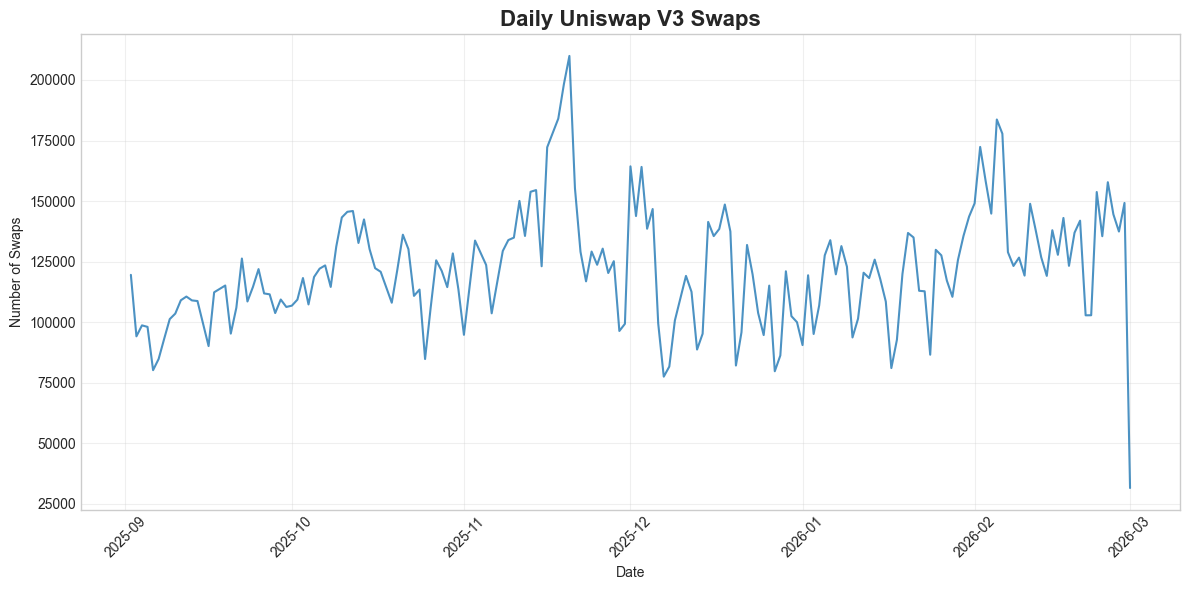

In [108]:
plt.figure(figsize=(12,6))

plt.plot(df['day'], df['swaps'], 
         linewidth=1.5, 
         alpha=0.8)

plt.title("Daily Uniswap V3 Swaps", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Swaps")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

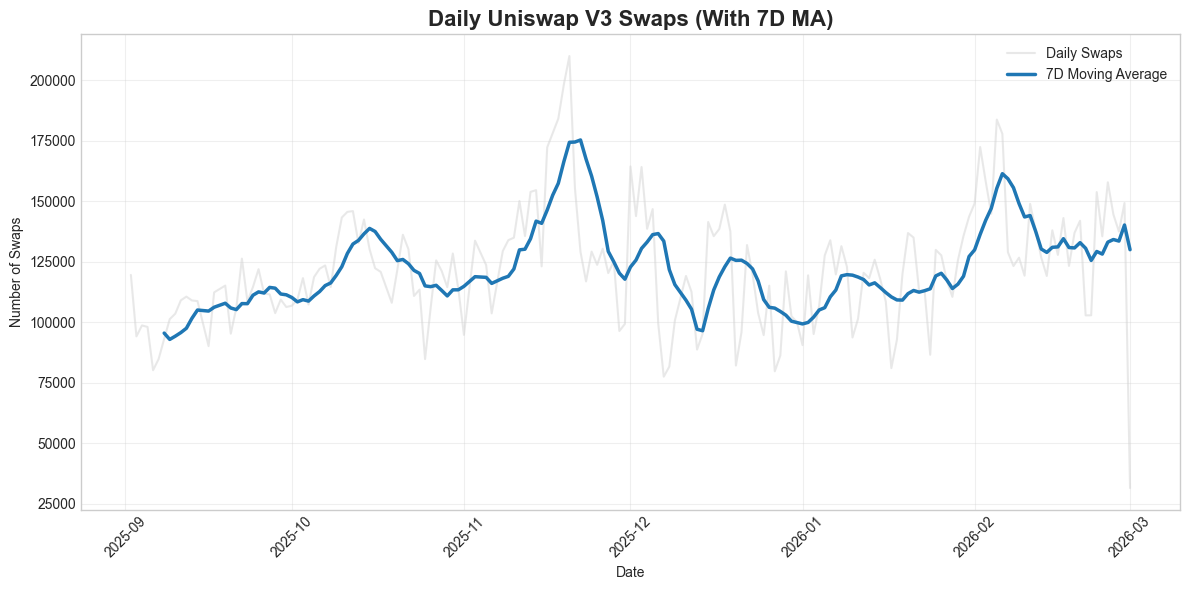

In [109]:
df['swaps_7d_ma'] = df['swaps'].rolling(7).mean()

plt.figure(figsize=(12,6))

plt.plot(df['day'], df['swaps'], 
         color='lightgray', 
         alpha=0.5, 
         label='Daily Swaps')

plt.plot(df['day'], df['swaps_7d_ma'], 
         linewidth=2.5, 
         label='7D Moving Average')

plt.title("Daily Uniswap V3 Swaps (With 7D MA)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Swaps")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

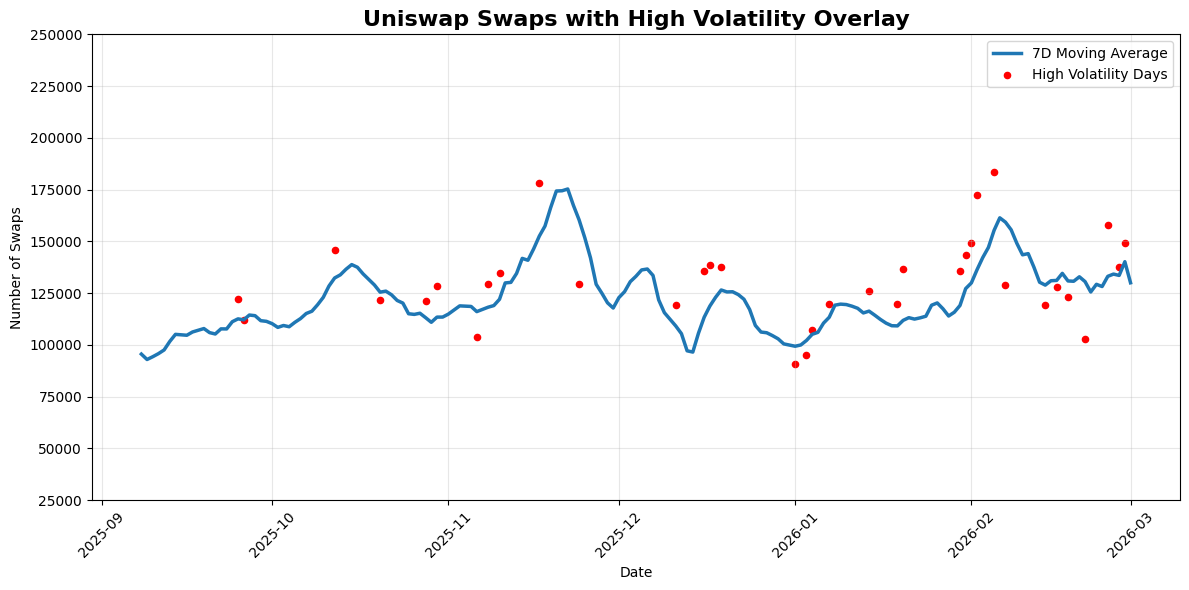

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['day'], df['swaps_7d_ma'], 
         linewidth=2.5, 
         label='7D Moving Average')

# Highlight high volatility days
high_vol_days = df[df['high_vol_day'] == 1]

plt.scatter(high_vol_days['day'], 
            high_vol_days['swaps'], 
            color='red', 
            s=20, 
            label='High Volatility Days')

plt.title("Uniswap Swaps with High Volatility Overlay", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Swaps")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

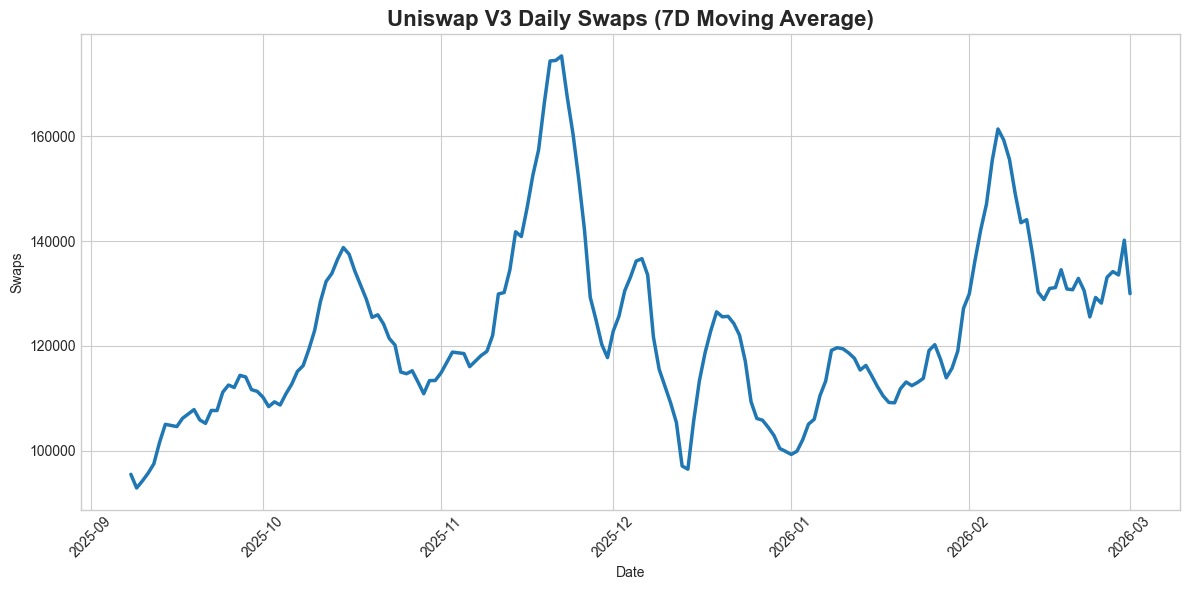

In [115]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df['day'], df['swaps_7d_ma'], 
        linewidth=2.5)

ax.set_title("Uniswap V3 Daily Swaps (7D Moving Average)", 
             fontsize=16, 
             fontweight='bold')

ax.set_xlabel("Date")
ax.set_ylabel("Swaps")

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

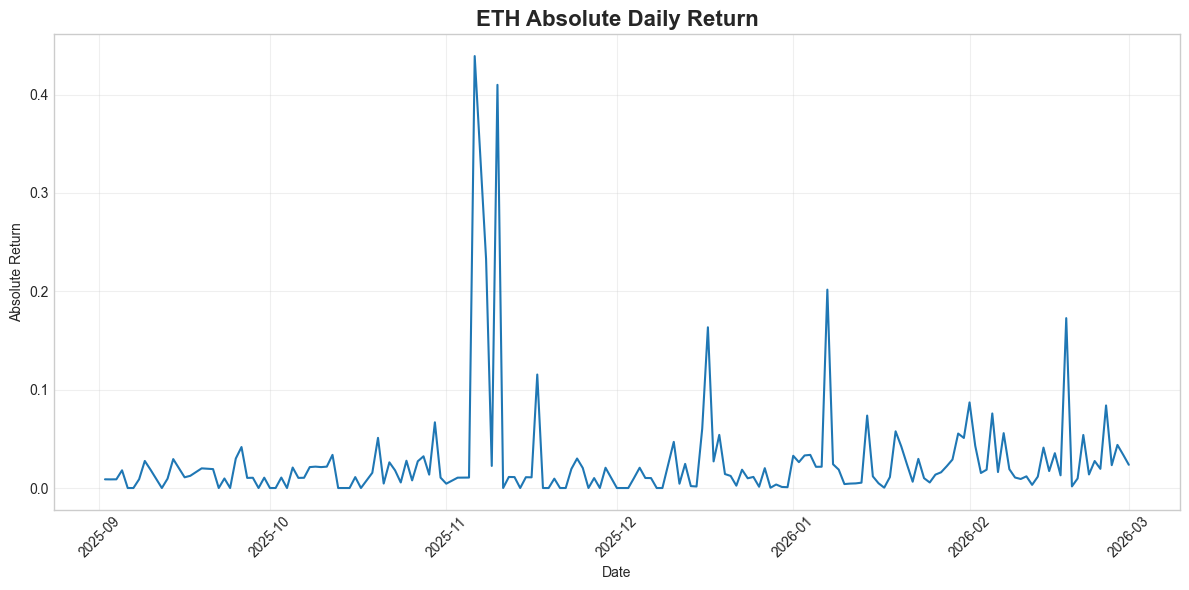

In [110]:
plt.figure(figsize=(12,6))

plt.plot(df['day'], df['abs_return'], 
         linewidth=1.5)

plt.title("ETH Absolute Daily Return", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Absolute Return")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

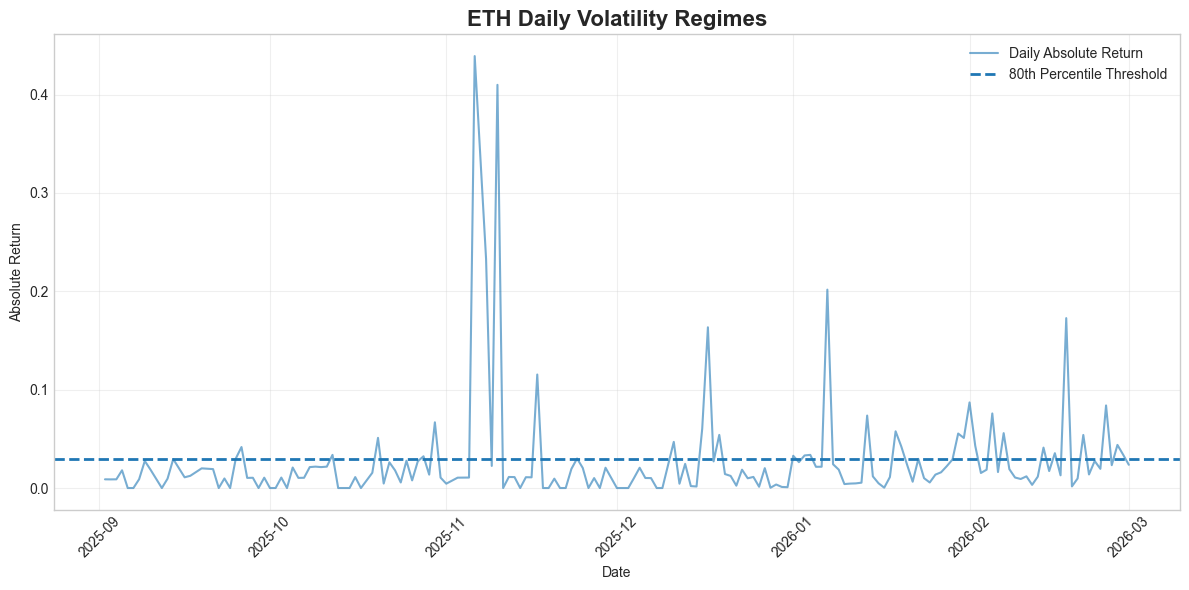

In [111]:
threshold = df['abs_return'].quantile(0.8)

plt.figure(figsize=(12,6))

plt.plot(df['day'], df['abs_return'], 
         alpha=0.6, 
         label='Daily Absolute Return')

plt.axhline(threshold, 
            linestyle='--', 
            linewidth=2, 
            label='80th Percentile Threshold')

plt.title("ETH Daily Volatility Regimes", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Absolute Return")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

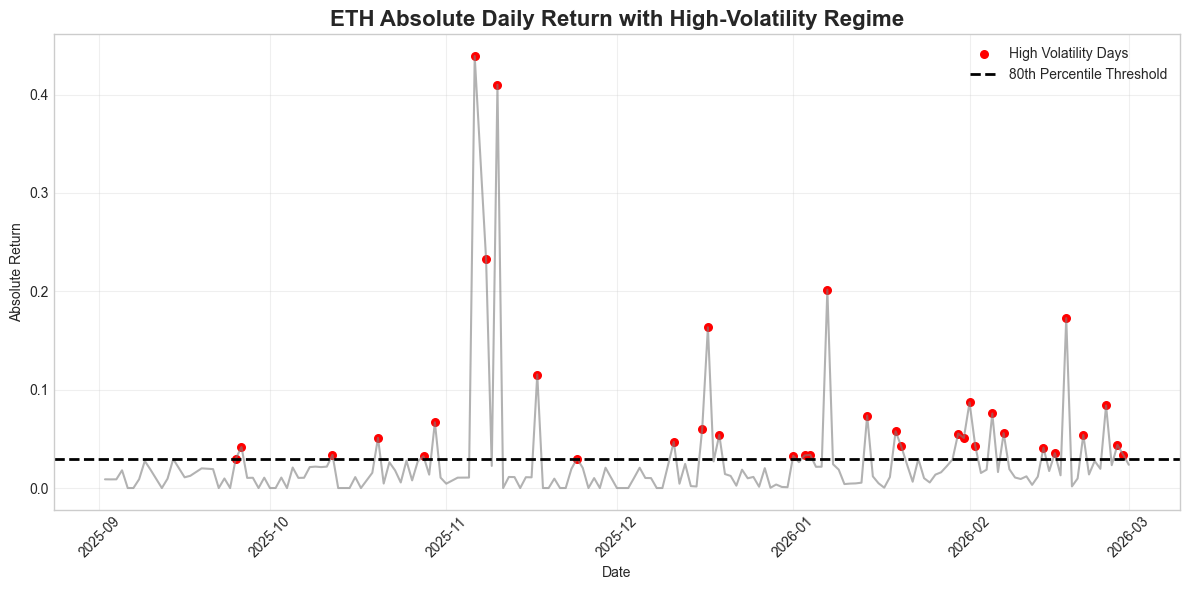

In [112]:
plt.figure(figsize=(12,6))

plt.plot(df['day'], df['abs_return'], 
         color='gray', 
         alpha=0.6)

high_vol = df[df['high_vol_day'] == 1]

plt.scatter(high_vol['day'], 
            high_vol['abs_return'], 
            color='red', 
            s=30, 
            label='High Volatility Days')

plt.axhline(threshold, 
            linestyle='--', 
            linewidth=2, 
            color='black',
            label='80th Percentile Threshold')

plt.title("ETH Absolute Daily Return with High-Volatility Regime", 
          fontsize=16, 
          fontweight='bold')

plt.xlabel("Date")
plt.ylabel("Absolute Return")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

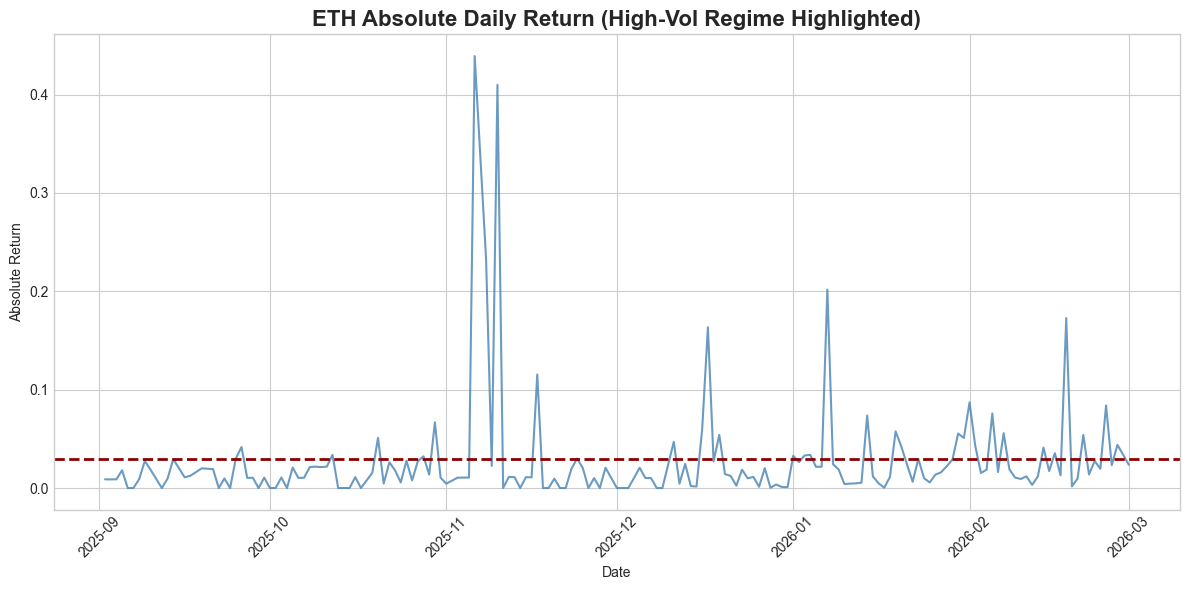

In [113]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df['day'], df['abs_return'], 
        color='steelblue', 
        alpha=0.8)

ax.axhline(threshold, 
           linestyle='--', 
           color='darkred', 
           linewidth=2)

ax.set_title("ETH Absolute Daily Return (High-Vol Regime Highlighted)", 
             fontsize=16, 
             fontweight='bold')

ax.set_xlabel("Date")
ax.set_ylabel("Absolute Return")

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Segment-Level Daily Metrics

In [ ]:
query_result_3 = dune.get_latest_result(6756709)
print(query_result_3)

rows = query_result_3.result.rows
segments_df = pd.DataFrame(rows)

segments_df.head()

# segments_df.to_csv('../data/segment_shares.csv', index=False)

ResultsResponse(execution_id='01KJPJ3VH9D9CX4B2MJT0RC5ZD', query_id=6756709, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 3, 2, 6, 0, 7, 978022, tzinfo=tzutc()), execution_started_at=datetime.datetime(2026, 3, 2, 6, 0, 17, 638175, tzinfo=tzutc()), execution_ended_at=datetime.datetime(2026, 3, 2, 6, 0, 37, 429413, tzinfo=tzutc()), expires_at=datetime.datetime(2026, 5, 31, 6, 0, 37, 429425, tzinfo=tzutc()), cancelled_at=None), result=ExecutionResult(rows=[{'day': '2025-09-02 00:00:00.000 UTC', 'segment': 'Mid', 'segment_volume': 33932058.83283069, 'unique_wallets': 3484, 'wallet_day_observations': 3484}, {'day': '2025-09-02 00:00:00.000 UTC', 'segment': 'Retail', 'segment_volume': 14270028.169916065, 'unique_wallets': 23715, 'wallet_day_observations': 23715}, {'day': '2025-09-02 00:00:00.000 UTC', 'segment': 'Whale', 'segment_volume': 1111113769.012342, 'unique_wallets': 2341, 'wallet_day_observations': 2341}, {'day': '202

,day,segment,segment_volume,unique_wallets,wallet_day_observations
0,2025-09-02 00:00:00.000 UTC,Mid,3.393206e+07,3484,3484
1,2025-09-02 00:00:00.000 UTC,Retail,1.427003e+07,23715,23715
2,2025-09-02 00:00:00.000 UTC,Whale,1.111114e+09,2341,2341
3,2025-09-03 00:00:00.000 UTC,Mid,2.967127e+07,3227,3227
4,2025-09-03 00:00:00.000 UTC,Retail,1.149850e+07,20045,20045


In [ ]:
segments = segments_df
segments['day'] = pd.to_datetime(segments['day'])

# compute segment volume share
# total daily volume
daily_total = segments.groupby('day')['segment_volume'].sum().reset_index()
daily_total.rename(columns={'segment_volume': 'total_volume'}, inplace=True)

segments = segments.merge(daily_total, on='day')

segments['volume_share'] = segments['segment_volume'] / segments['total_volume']

# pivot for easier analysis
pivot = segments.pivot(index='day', columns='segment', values='volume_share').reset_index()

# merge with volatility
full = pivot.merge(df[['day', 'high_vol_day']], on='day')

full.head()

,day,Mid,Retail,Whale,high_vol_day
0,2025-09-02 00:00:00+00:00,0.029269,0.012309,0.958422,0
1,2025-09-03 00:00:00+00:00,0.031843,0.012340,0.955816,0
2,2025-09-04 00:00:00+00:00,0.029956,0.013443,0.956601,0
3,2025-09-05 00:00:00+00:00,0.024825,0.009943,0.965232,0
4,2025-09-06 00:00:00+00:00,0.040033,0.019072,0.940895,0


In [96]:
# compare whale share on high vs low vol days
full.groupby('high_vol_day')['Whale'].mean()

high_vol_day
0    0.949640
1    0.955343
Name: Whale, dtype: float64

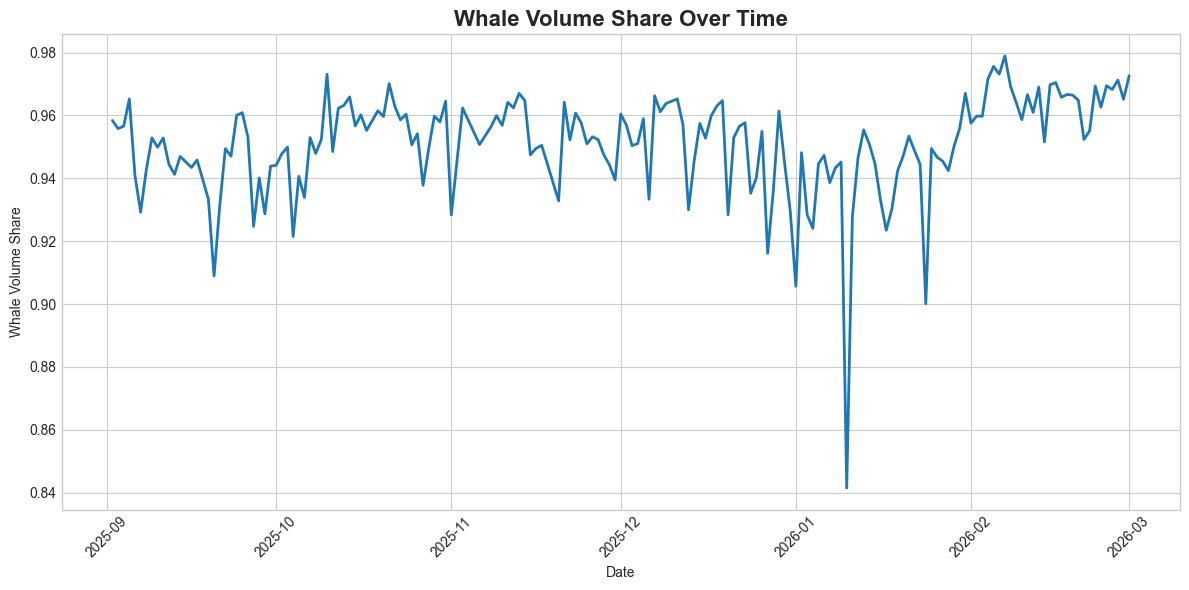

In [119]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(12,6))

plt.plot(full['day'], full['Whale'], 
         linewidth=2)

plt.title("Whale Volume Share Over Time", 
          fontsize=16, 
          fontweight='bold')

plt.xlabel("Date")
plt.ylabel("Whale Volume Share")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

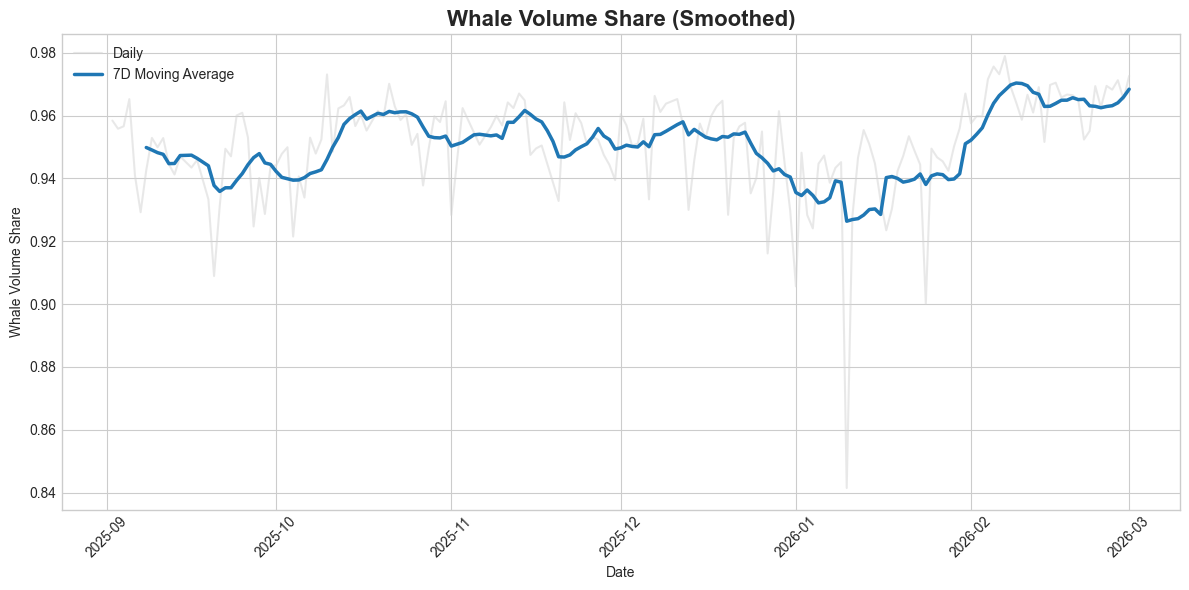

In [116]:
full['whale_7d_ma'] = full['Whale'].rolling(7).mean()

plt.figure(figsize=(12,6))

plt.plot(full['day'], full['Whale'], 
         color='lightgray', 
         alpha=0.5, 
         label='Daily')

plt.plot(full['day'], full['whale_7d_ma'], 
         linewidth=2.5, 
         label='7D Moving Average')

plt.title("Whale Volume Share (Smoothed)", 
          fontsize=16, 
          fontweight='bold')

plt.xlabel("Date")
plt.ylabel("Whale Volume Share")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

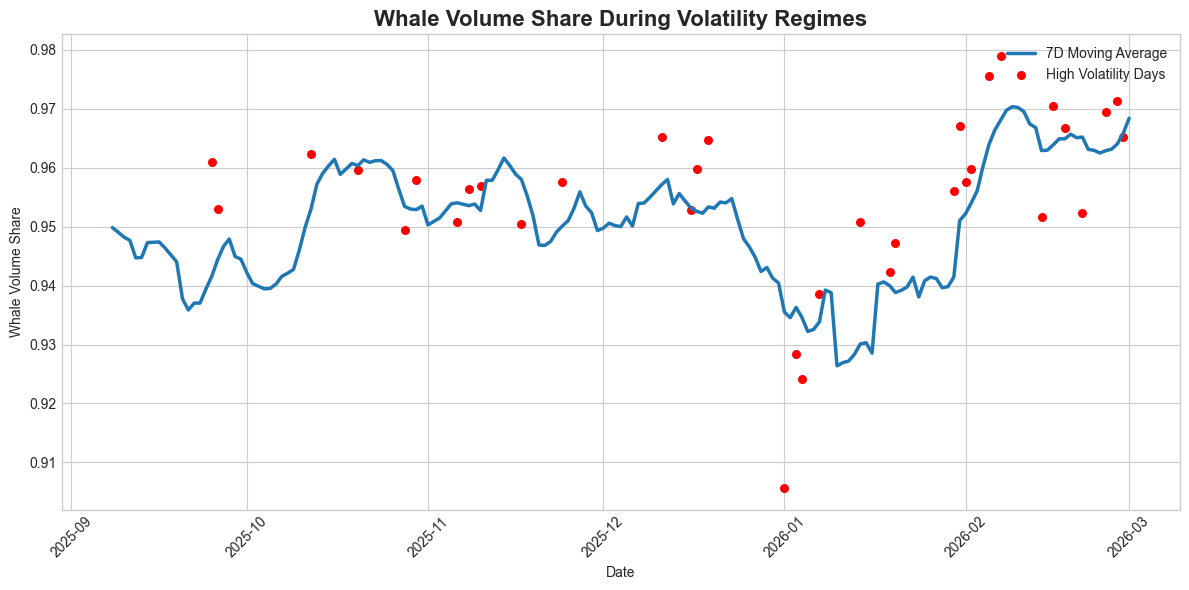

In [117]:
plt.figure(figsize=(12,6))

plt.plot(full['day'], full['whale_7d_ma'], 
         linewidth=2.5, 
         label='7D Moving Average')

high_vol = full[full['high_vol_day'] == 1]

plt.scatter(high_vol['day'], 
            high_vol['Whale'], 
            color='red', 
            s=30, 
            label='High Volatility Days')

plt.title("Whale Volume Share During Volatility Regimes", 
          fontsize=16, 
          fontweight='bold')

plt.xlabel("Date")
plt.ylabel("Whale Volume Share")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

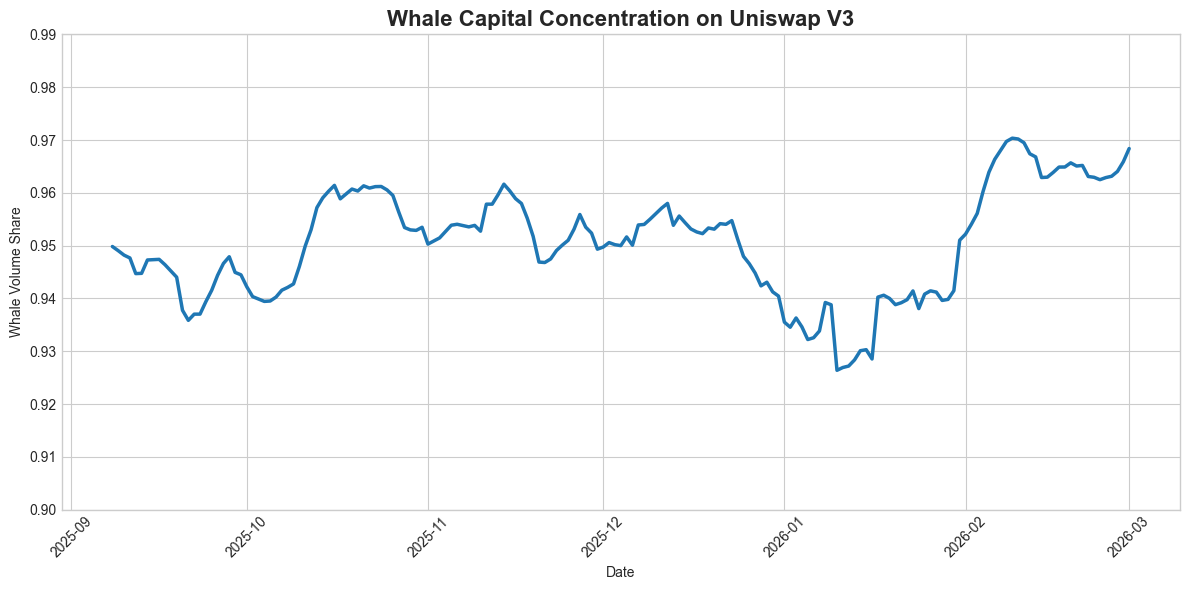

In [118]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(full['day'], full['whale_7d_ma'], 
        linewidth=2.5)

ax.set_ylim(0.90, 0.99)

ax.set_title("Whale Capital Concentration on Uniswap V3", 
             fontsize=16, 
             fontweight='bold')

ax.set_xlabel("Date")
ax.set_ylabel("Whale Volume Share")

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [98]:
# statistical test
whale_high = full[full['high_vol_day'] == 1]['Whale']
whale_low = full[full['high_vol_day'] == 0]['Whale']

ttest_ind(whale_high, whale_low, equal_var=False)

TtestResult(statistic=np.float64(2.0201388521423143), pvalue=np.float64(0.04800454387228252), df=np.float64(57.89242601658029))